In [1]:
import asyncio
from datetime import time

import altair as alt
import httpx
import marimo
import pandas as pd
import seaborn as sns

In [2]:
BASE_URL = "https://transport.opendata.ch/v1/connections"
ORIGIN_STATION = "Zurich HB"
HUB_DESTINATIONS = [
    "Winterthur",
    "Zurich Oerlikon",
    "Zug",
    "Baden",
    "Uster",
]
REQUEST_LIMIT = 20

In [3]:
async def fetch_connections(
    from_station: str,
    to_station: str,
    *,
    limit: int = REQUEST_LIMIT,
) -> dict:
    params = {
        "from": from_station,
        "to": to_station,
        "limit": limit,
    }
    async with httpx.AsyncClient(timeout=20) as client:
        response = await client.get(BASE_URL, params=params)
        response.raise_for_status()
        return response.json()

async def fetch_for_destinations(
    from_station: str,
    destinations: list[str],
    *,
    limit: int = REQUEST_LIMIT,
) -> list[dict]:
    tasks = [
        fetch_connections(from_station, destination, limit=limit)
        for destination in destinations
    ]
    results = await asyncio.gather(*tasks, return_exceptions=True)

    payloads = []
    for destination, result in zip(destinations, results):
        if isinstance(result, Exception):
            payloads.append(
                {
                    "query_from": from_station,
                    "query_to": destination,
                    "connections": [],
                    "error": str(result),
                }
            )
        else:
            payloads.append(
                {
                    "query_from": from_station,
                    "query_to": destination,
                    "connections": result.get("connections", []),
                    "error": None,
                }
            )
    return payloads

In [4]:
WEEKDAY_ORDER = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

def _safe_to_datetime(value):
    return pd.to_datetime(value, errors="coerce", utc=True)

def _compute_delay_minutes(scheduled, prognosis) -> float:
    if pd.isna(scheduled):
        return 0.0
    if pd.isna(prognosis):
        return 0.0
    return (prognosis - scheduled).total_seconds() / 60.0

def flatten_connections(payloads):
    rows: list[dict] = []
    for payload in payloads:
        query = payload.get("query_from", payload.get("from", ""))
        destination = payload.get("query_to", payload.get("to", ""))

        if isinstance(query, dict):
            query = (query.get("station") or {}).get("name", "")
        if isinstance(destination, dict):
            destination = (destination.get("station") or {}).get("name", "")

        connections = payload.get("connections", [])

        for connection in connections:
            from_obj = connection.get("from", {})
            to_obj = connection.get("to", {})
            prognosis_from = (from_obj.get("prognosis") or {})
            prognosis_to = (to_obj.get("prognosis") or {})

            departure_scheduled = _safe_to_datetime(from_obj.get("departure"))
            arrival_scheduled = _safe_to_datetime(to_obj.get("arrival"))
            departure_prognosis = _safe_to_datetime(
                prognosis_from.get("departure")
            )
            arrival_prognosis = _safe_to_datetime(prognosis_to.get("arrival"))

            dep_delay = _compute_delay_minutes(
                departure_scheduled,
                departure_prognosis,
            )
            arr_delay = _compute_delay_minutes(
                arrival_scheduled,
                arrival_prognosis,
            )
            delay_minutes = arr_delay if not pd.isna(arrival_prognosis) else dep_delay

            rows.append(
                {
                    "route_from": query,
                    "route_to": destination,
                    "departure_scheduled": departure_scheduled,
                    "arrival_scheduled": arrival_scheduled,
                    "departure_prognosis": departure_prognosis,
                    "arrival_prognosis": arrival_prognosis,
                    "transfers": len(connection.get("sections", [])) - 1,
                    "duration": connection.get("duration"),
                    "departure_delay_minutes": dep_delay,
                    "arrival_delay_minutes": arr_delay,
                    "delay_minutes": delay_minutes,
                }
            )

    if not rows:
        return pd.DataFrame(
            columns=[
                "route_from",
                "route_to",
                "departure_scheduled",
                "arrival_scheduled",
                "departure_prognosis",
                "arrival_prognosis",
                "transfers",
                "duration",
                "departure_delay_minutes",
                "arrival_delay_minutes",
                "delay_minutes",
                "is_peak_hour",
                "day_of_week",
            ]
        )

    frame = pd.DataFrame(rows)

    departure_local = frame["departure_scheduled"].dt.tz_convert("Europe/Zurich")
    frame["is_peak_hour"] = departure_local.dt.time.apply(
        lambda t: (
            time(7, 0) <= t <= time(9, 0)
            or time(16, 0) <= t <= time(19, 0)
        )
        if pd.notna(t)
        else False
    )

    frame["day_of_week"] = pd.Categorical(
        departure_local.dt.day_name(),
        categories=WEEKDAY_ORDER,
        ordered=True,
    )
    frame["transfers"] = frame["transfers"].clip(lower=0)

    return frame

def most_reliable_connections(frame, top_n: int = 5):
    if frame.empty:
        return pd.DataFrame(columns=["route_to", "avg_delay_minutes", "trips"])

    summary = (
        frame.groupby(["route_from", "route_to", "transfers"], as_index=False)
        .agg(
            avg_delay_minutes=("delay_minutes", "mean"),
            median_delay_minutes=("delay_minutes", "median"),
            trips=("delay_minutes", "size"),
        )
        .sort_values(["avg_delay_minutes", "median_delay_minutes", "transfers"])
        .head(top_n)
        .reset_index(drop=True)
    )
    return summary

In [5]:
marimo.md("## Zurich Commuting and Delay Analyzer")
destination_dropdown = marimo.ui.dropdown(
    options=HUB_DESTINATIONS,
    value="Winterthur",
    label="Destination Station",
)
transfer_slider = marimo.ui.slider(
    start=0,
    stop=4,
    value=2,
    step=1,
    label="Maximum Transfers",
)
marimo.hstack([destination_dropdown, transfer_slider], justify="space-between")

_FlexContainerHtml()

In [6]:
payloads = await fetch_for_destinations(
    ORIGIN_STATION, HUB_DESTINATIONS, limit=16
)
fetch_errors = [
    f"{payload['query_to']}: {payload['error']}"
    for payload in payloads
    if payload.get("error")
]
all_connections = flatten_connections(payloads)
all_connections.head()
fetch_errors
all_connections.shape

(80, 13)

In [7]:
all_connections.columns

Index(['route_from', 'route_to', 'departure_scheduled', 'arrival_scheduled',
       'departure_prognosis', 'arrival_prognosis', 'transfers', 'duration',
       'departure_delay_minutes', 'arrival_delay_minutes', 'delay_minutes',
       'is_peak_hour', 'day_of_week'],
      dtype='str')

In [8]:
all_connections.dtypes

route_from                                 str
route_to                                   str
departure_scheduled        datetime64[us, UTC]
arrival_scheduled          datetime64[us, UTC]
departure_prognosis        datetime64[us, UTC]
arrival_prognosis                datetime64[s]
transfers                                int64
duration                                   str
departure_delay_minutes                float64
arrival_delay_minutes                  float64
delay_minutes                          float64
is_peak_hour                              bool
day_of_week                           category
dtype: object

In [9]:
summary_all = {
    "rows": len(all_connections),
    "columns": all_connections.shape[1],
    "mean_delay": round(all_connections["delay_minutes"].mean(), 2),
    "median_delay": round(all_connections["delay_minutes"].median(), 2),
    "max_delay": round(all_connections["delay_minutes"].max(), 2),
    "min_delay": round(all_connections["delay_minutes"].min(), 2),
    "mean_transfers": round(all_connections["transfers"].mean(), 2),
}

marimo.ui.table([{"metric": k, "value": v} for k, v in summary_all.items()])

table()

In [10]:
all_connections.describe(include="all").transpose().reset_index()

,index,count,unique,top,freq,mean,min,25%,50%,75%,max,std
0,route_from,80,1,Zurich HB,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,route_to,80,5,Winterthur,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,departure_scheduled,80,NaN,NaN,NaN,2026-03-25 11:14:58.500000+00:00,2026-03-25 10:12:00+00:00,2026-03-25 10:39:00+00:00,2026-03-25 11:05:30+00:00,2026-03-25 11:39:45+00:00,2026-03-25 13:14:00+00:00,NaN
3,arrival_scheduled,80,NaN,NaN,NaN,2026-03-25 11:34:36+00:00,2026-03-25 10:17:00+00:00,2026-03-25 10:57:00+00:00,2026-03-25 11:26:30+00:00,2026-03-25 12:05:45+00:00,2026-03-25 13:42:00+00:00,NaN
4,departure_prognosis,72,NaN,NaN,NaN,2026-03-25 11:07:45.833333+00:00,2026-03-25 10:12:00+00:00,2026-03-25 10:38:30+00:00,2026-03-25 11:03:00+00:00,2026-03-25 11:33:00+00:00,2026-03-25 12:44:00+00:00,NaN
5,arrival_prognosis,0,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaT,NaT,NaN
6,transfers,80.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,duration,80,19,00d00:28:00,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,departure_delay_minutes,80.0,NaN,NaN,NaN,0.15,0.0,0.0,0.0,0.0,1.0,0.359324
9,arrival_delay_minutes,80.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
all_connections["route_to"].value_counts()

route_to
Winterthur         16
Zurich Oerlikon    16
Zug                16
Baden              16
Uster              16
Name: count, dtype: int64

In [12]:
all_connections.groupby("route_to")["delay_minutes"].mean().sort_values(ascending=False)

route_to
Winterthur         0.375
Uster              0.250
Zug                0.125
Baden              0.000
Zurich Oerlikon    0.000
Name: delay_minutes, dtype: float64

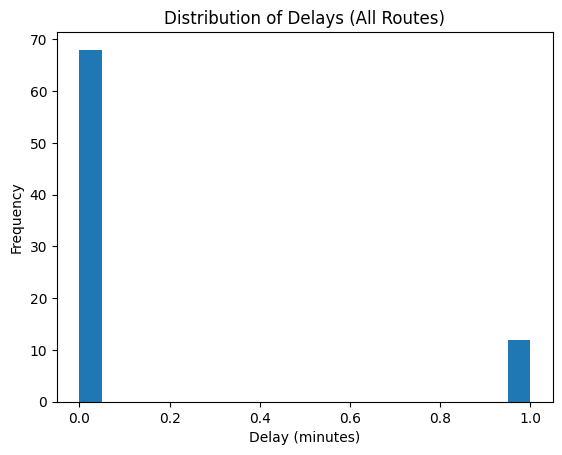

In [13]:
import matplotlib.pyplot as plt

plt.hist(all_connections["delay_minutes"], bins=20)
plt.title("Distribution of Delays (All Routes)")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

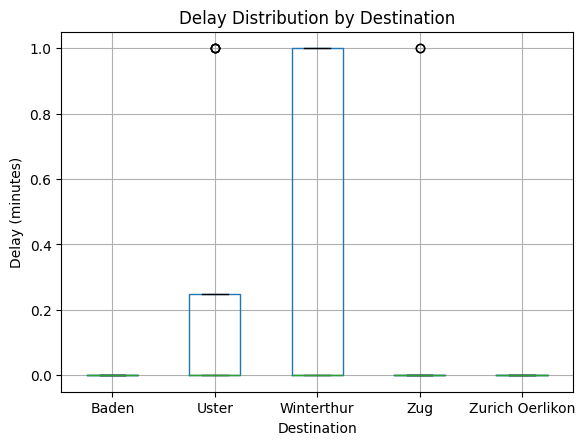

In [14]:
all_connections.boxplot(column="delay_minutes", by="route_to")
plt.title("Delay Distribution by Destination")
plt.suptitle("")
plt.xlabel("Destination")
plt.ylabel("Delay (minutes)")
plt.show()

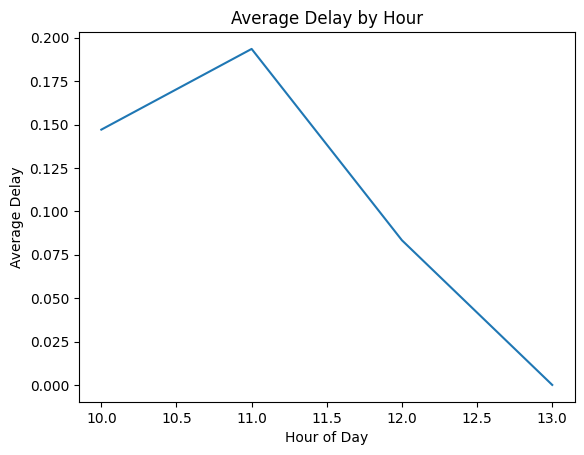

In [15]:
all_connections["hour"] = all_connections["departure_scheduled"].dt.hour

all_connections.groupby("hour")["delay_minutes"].mean().plot(kind="line")
plt.title("Average Delay by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay")
plt.show()

In [16]:
marimo.md("## Advanced EDA")

_md()

In [17]:
# Convertir a datetime si no lo está
all_connections["departure_scheduled"] = pd.to_datetime(all_connections["departure_scheduled"])
all_connections["arrival_scheduled"] = pd.to_datetime(all_connections["arrival_scheduled"])

# Hora del día
all_connections["hour"] = all_connections["departure_scheduled"].dt.hour

# Día de la semana
all_connections["day_of_week"] = all_connections["departure_scheduled"].dt.day_name()

# Variable binaria de retraso (clave)
all_connections["is_delayed"] = (all_connections["delay_minutes"] > 0).astype(int)

In [18]:
delay_by_route = (
    all_connections.groupby("route_to")["is_delayed"]
    .mean()
    .sort_values(ascending=False)
)

delay_by_route

route_to
Winterthur         0.375
Uster              0.250
Zug                0.125
Baden              0.000
Zurich Oerlikon    0.000
Name: is_delayed, dtype: float64

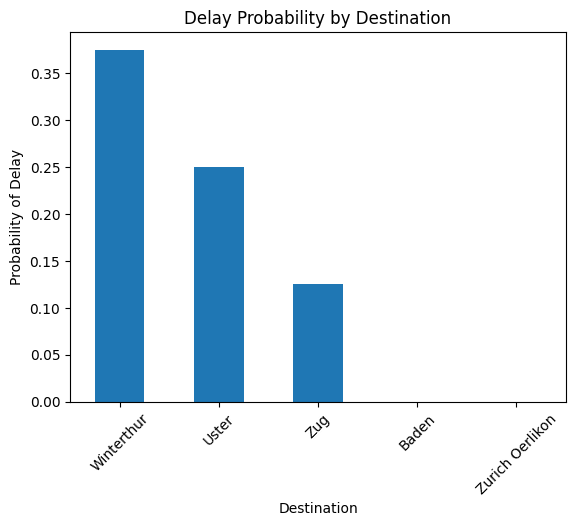

In [19]:
delay_by_route.plot(kind="bar")
plt.title("Delay Probability by Destination")
plt.ylabel("Probability of Delay")
plt.xlabel("Destination")
plt.xticks(rotation=45)
plt.show()

In [20]:
delay_by_hour = (
    all_connections.groupby("hour")["is_delayed"]
    .mean()
)

delay_by_hour

hour
10    0.147059
11    0.193548
12    0.083333
13    0.000000
Name: is_delayed, dtype: float64

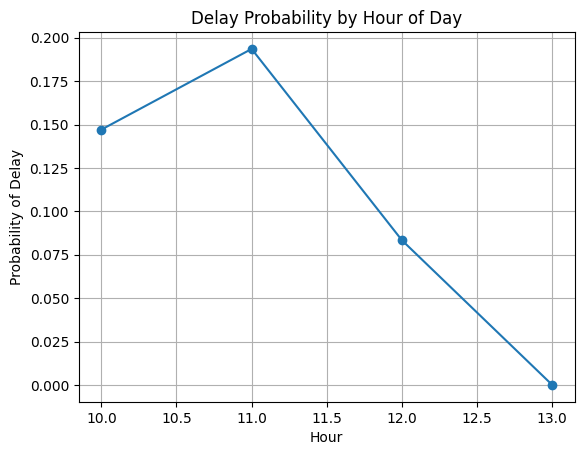

In [21]:
delay_by_hour.plot(marker="o")
plt.title("Delay Probability by Hour of Day")
plt.ylabel("Probability of Delay")
plt.xlabel("Hour")
plt.grid()
plt.show()

In [22]:
pivot_delay = pd.pivot_table(
    all_connections,
    values="is_delayed",
    index="hour",
    columns="route_to",
    aggfunc="mean"
)

pivot_delay

route_to,Baden,Uster,Winterthur,Zug,Zurich Oerlikon
hour,,,,,
10,0.0,0.166667,0.375,0.250000,0.0
11,0.0,0.250000,0.375,0.142857,0.0
12,0.0,0.500000,NaN,0.000000,NaN
13,0.0,NaN,NaN,NaN,NaN


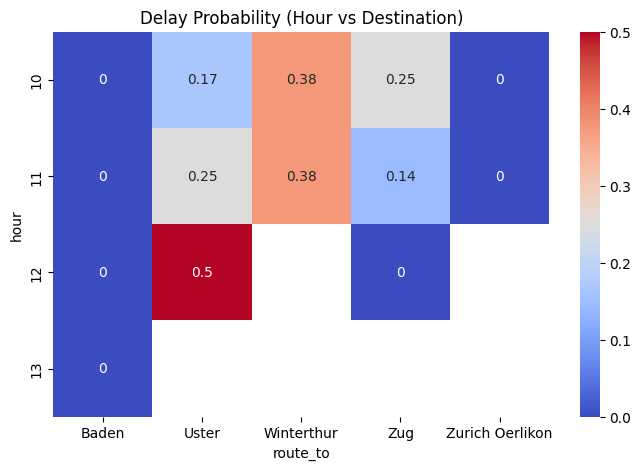

In [23]:

plt.figure(figsize=(8,5))
sns.heatmap(pivot_delay, annot=True, cmap="coolwarm")
plt.title("Delay Probability (Hour vs Destination)")
plt.show()

In [24]:
all_connections[["delay_minutes", "transfers", "hour"]].corr()

,delay_minutes,transfers,hour
delay_minutes,1.000000,NaN,-0.067675
transfers,NaN,NaN,NaN
hour,-0.067675,NaN,1.000000


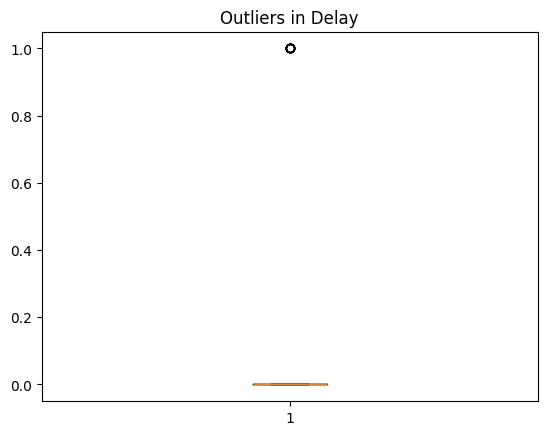

In [25]:
plt.boxplot(all_connections["delay_minutes"])
plt.title("Outliers in Delay")
plt.show()

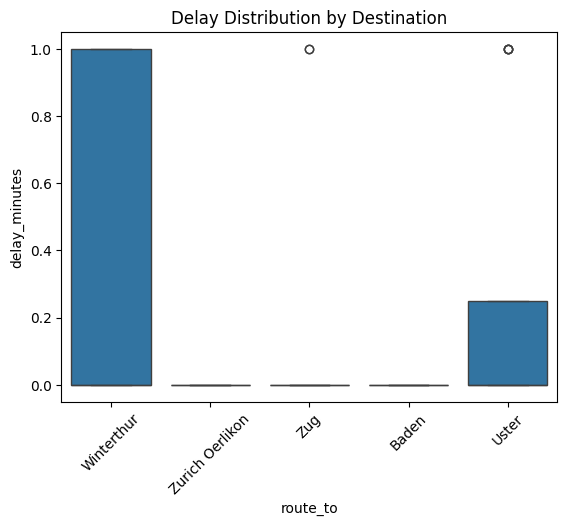

In [26]:


sns.boxplot(
    data=all_connections,
    x="route_to",
    y="delay_minutes"
)

plt.title("Delay Distribution by Destination")
plt.xticks(rotation=45)
plt.show()

In [27]:
for route, prob in delay_by_route.items():
    print(f"{route}: {round(prob*100,2)}% of trains delayed")

Winterthur: 37.5% of trains delayed
Uster: 25.0% of trains delayed
Zug: 12.5% of trains delayed
Baden: 0.0% of trains delayed
Zurich Oerlikon: 0.0% of trains delayed


In [28]:
if fetch_errors:
    marimo.md("### Data Fetch Warnings")
    marimo.md("\\n".join([f"- {message}" for message in fetch_errors]))

In [29]:
selected_destination = destination_dropdown.value
selected_data = all_connections[all_connections["route_to"] == selected_destination].copy()

In [30]:
filtered_data = selected_data[selected_data["transfers"] <= transfer_slider.value].copy()

In [31]:
marimo.md("### Delay Distribution")
if filtered_data.empty:
    marimo.md("No data available for the selected filters.")
else:
    histogram = (
        alt.Chart(filtered_data)
        .mark_bar()
        .encode(
            x=alt.X("delay_minutes:Q", bin=alt.Bin(maxbins=30), title="Delay (minutes)"),
            y=alt.Y("count():Q", title="Connections"),
            tooltip=[
                alt.Tooltip("count():Q", title="Connections"),
            ],
        )
        .properties(height=320)
    )
    histogram

In [32]:
#MARIO
summary = {
    "rows": len(filtered_data),
    "columns": filtered_data.shape[1],
    "mean_delay": round(filtered_data["delay_minutes"].mean(), 2),
    "median_delay": round(filtered_data["delay_minutes"].median(), 2),
    "max_delay": round(filtered_data["delay_minutes"].max(), 2),
    "min_delay": round(filtered_data["delay_minutes"].min(), 2),
    "mean_transfers": round(filtered_data["transfers"].mean(), 2),
}

marimo.ui.table([{"metric": k, "value": v} for k, v in summary.items()])
summary

{'rows': 16,
 'columns': 15,
 'mean_delay': 0.38,
 'median_delay': 0.0,
 'max_delay': 1.0,
 'min_delay': 0.0,
 'mean_transfers': 0.0}

In [33]:
#MARIO
filtered_data.describe(include="all").transpose().reset_index()

,index,count,unique,top,freq,mean,min,25%,50%,75%,max,std
0,route_from,16,1,Zurich HB,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,route_to,16,1,Winterthur,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,departure_scheduled,16,NaN,NaN,NaN,2026-03-25 10:54:41.250000+00:00,2026-03-25 10:16:00+00:00,2026-03-25 10:33:30+00:00,2026-03-25 10:58:00+00:00,2026-03-25 11:10:00+00:00,2026-03-25 11:32:00+00:00,NaN
3,arrival_scheduled,16,NaN,NaN,NaN,2026-03-25 11:18:26.250000+00:00,2026-03-25 10:38:00+00:00,2026-03-25 10:58:30+00:00,2026-03-25 11:20:00+00:00,2026-03-25 11:36:30+00:00,2026-03-25 11:57:00+00:00,NaN
4,departure_prognosis,16,NaN,NaN,NaN,2026-03-25 10:55:03.750000+00:00,2026-03-25 10:17:00+00:00,2026-03-25 10:33:30+00:00,2026-03-25 10:58:30+00:00,2026-03-25 11:10:15+00:00,2026-03-25 11:32:00+00:00,NaN
5,arrival_prognosis,0,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaT,NaT,NaN
6,transfers,16.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,duration,16,6,00d00:25:00,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,departure_delay_minutes,16.0,NaN,NaN,NaN,0.375,0.0,0.0,0.0,1.0,1.0,0.5
9,arrival_delay_minutes,16.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
marimo.md("### Top 5 Most Reliable Connections")
reliability_table = most_reliable_connections(filtered_data, top_n=5)
if reliability_table.empty:
    marimo.md("No reliable connections found for the selected filters.")
else:
    marimo.ui.table(reliability_table)

In [35]:

marimo.md("### Filtered Data Preview")
x= marimo.ui.table(
    filtered_data[
        [
            "route_from",
            "route_to",
            "departure_scheduled",
            "arrival_scheduled",
            "transfers",
            "delay_minutes",
            "is_peak_hour",
            "day_of_week",
        ]
    ].sort_values("departure_scheduled")
)


In [36]:
marimo.md("### Demo-Safe Mock Delay Chart")

mock_commute_data = pd.DataFrame(
    [
        {"route": "Zurich HB → Winterthur", "delay_minutes": 2, "time": "07:12"},
        {"route": "Zurich HB → Winterthur", "delay_minutes": 5, "time": "07:42"},
        {"route": "Zurich HB → Winterthur", "delay_minutes": 8, "time": "08:12"},
        {"route": "Zurich HB → Winterthur", "delay_minutes": 11, "time": "08:42"},
        {"route": "Zurich HB → Winterthur", "delay_minutes": 14, "time": "09:12"},
    ]
)

max_delay = marimo.ui.slider(
    start=0,
    stop=20,
    step=1,
    value=14,
    label="Max delay (minutes)",
)

In [37]:
filtered_mock_data = mock_commute_data[
    mock_commute_data["delay_minutes"] <= max_delay.value
]

chart = (
    alt.Chart(filtered_mock_data)
    .mark_bar()
    .encode(
        x=alt.X("time:N", title="Time"),
        y=alt.Y("delay_minutes:Q", title="Delay (minutes)"),
        tooltip=["route:N", "time:N", "delay_minutes:Q"],
    )
    .properties(height=280)
)

marimo.vstack([max_delay, chart, marimo.ui.table(filtered_mock_data)])
chart

alt.Chart(...)